# Visualizing Positivity Analysis for University Campus Health Surveillance Project 
# Author: Ari M.
# Description: Visualizes infection positivity trends by disease, population group, age group, and vaccination status
# Goal: Visualize infection positivity trends on campus to identify high-risk groups and evaluate potential impact of vaccination status.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Display full columns
pd.set_option("display.max_columns", None)

# Load cleaned datasets
patients = pd.read_csv("../data/cleaned/patients_cleaned.csv")
tests = pd.read_csv("../data/cleaned/tests_cleaned.csv")
vaccinations = pd.read_csv("../data/cleaned/vaccinations_cleaned.csv")

In [3]:
positivity_rate_by_disease = pd.read_csv("../data/cleaned/positivity_rate_by_disease.csv", index_col=0)
positivity_by_age_population = pd.read_csv("../data/cleaned/positivity_by_age_population.csv", index_col=0)

print("Data loaded successfully!")

Data loaded successfully!


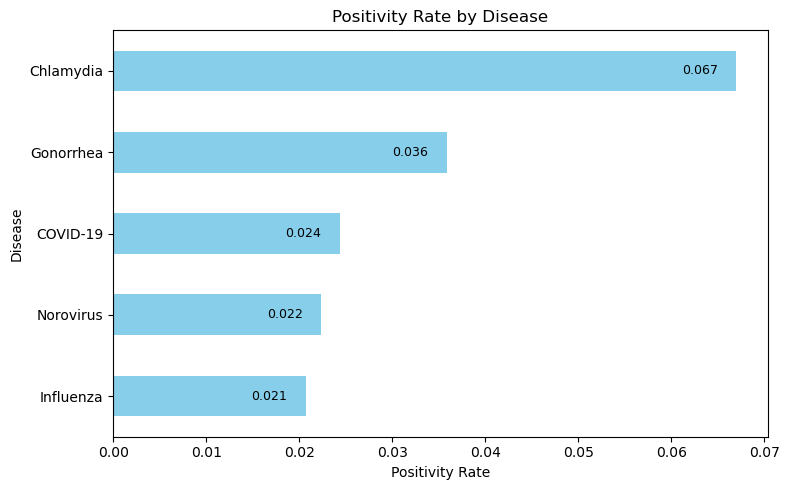

In [4]:
# Horizontal bar chart for disease positivity
ax = positivity_rate_by_disease.sort_values("is_positive").plot(
    kind="barh",
    figsize=(8,5),
    legend=False,
    color="skyblue"
)

plt.title("Positivity Rate by Disease")
plt.xlabel("Positivity Rate")
plt.ylabel("Disease")

# Adding data labels
for i, v in enumerate(positivity_rate_by_disease.sort_values("is_positive")["is_positive"]):
    ax.text(v - 0.002, i, f"{v:.3f}", va='center', ha='right', color='black', fontsize=9)

plt.tight_layout()
plt.savefig("../dashboards/positivity_by_disease.png")
plt.show()

### Observation

Chlamydia stands out with the highest positivity rate, followed by Gonorrhea.

I expected respiratory illnesses like Influenza to be higher, but they actually show lower positivity here. 
This might be because those tests are used more broadly (including precautionary testing), while STI testing may be more targeted.

## Positivity Rate by Disease and Population
To better understand how infection patterns differ between students and staff, I will break down positivity rates by both disease and population group.

In [5]:
# Merge datasets (if not already done earlier)
tests_merged = tests.merge(patients, on="patient_id", how="left")

# Ensure positivity column exists
if "is_positive" not in tests_merged.columns:
    tests_merged["is_positive"] = tests_merged["test_result"] == "Positive"

# Calculate positivity by disease and population
positivity_by_disease_population = (
    tests_merged
    .groupby(["disease", "staff_or_student_status"])["is_positive"]
    .mean()
    .unstack()
)

print ("Completed positivity by disease and population")

Completed positivity by disease and population


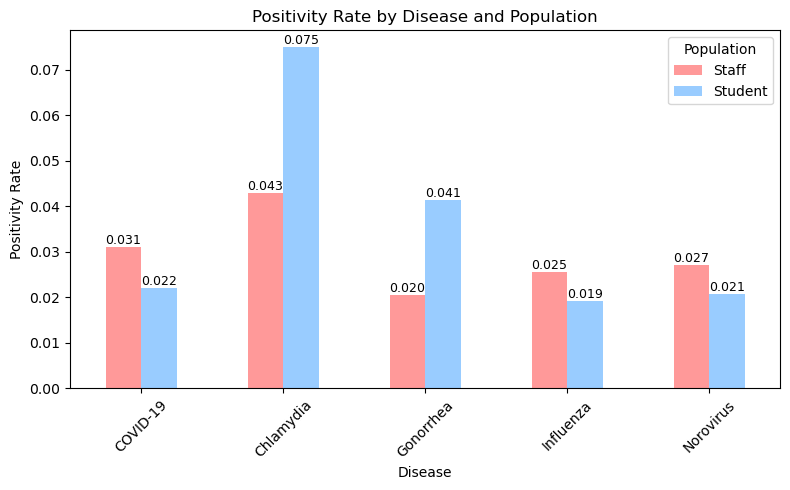

In [6]:
ax = positivity_by_disease_population.plot(
    kind="bar",
    figsize=(8,5),
    color=["#FF9999","#99CCFF"]
)

plt.title("Positivity Rate by Disease and Population")
plt.xlabel("Disease")
plt.ylabel("Positivity Rate")
plt.xticks(rotation=45)
plt.legend(title="Population")

# Add labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.savefig("../dashboards/positivity_by_disease_population.png")
plt.show()


### Observation

Breaking this down by both disease and population shows that differences between students and staff are not consistent across all diseases.

Sexually transmitted infections (STIs) like Chlamydia and Gonorrhea appear to have higher positivity rates among students.

In contrast, respiratory illnesses such as COVID-19 and Influenza show smaller differences between the two groups.

This suggests that infection risk may vary more by disease type than by population group alone.

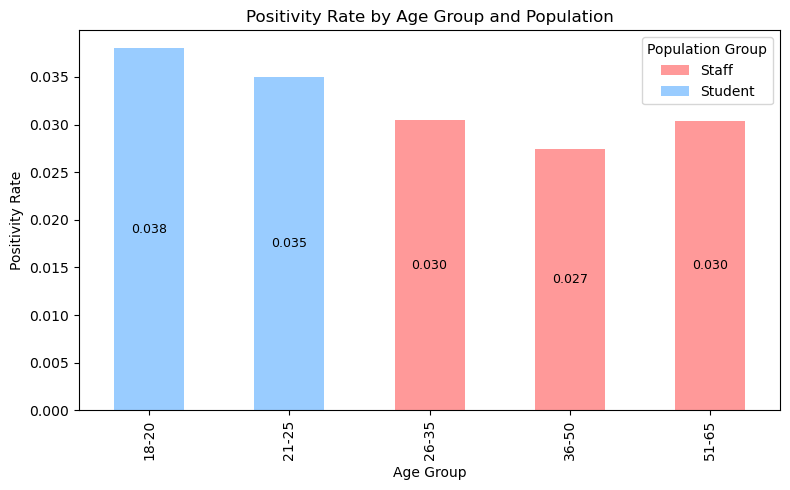

In [7]:
# I’m going to create a bar chart with data labels

# Setting  age_group as categorical for proper order
ax = positivity_by_age_population.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#FF9999","#99CCFF"]
)

plt.title("Positivity Rate by Age Group and Population")
plt.xlabel("Age Group")
plt.ylabel("Positivity Rate")
plt.legend(title="Population Group")

# Add labels for each segment
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # skip zero-height bars
        ax.text(
            p.get_x() + p.get_width()/2,
            p.get_y() + height/2,
            f"{height:.3f}",
            ha='center',
            va='center',
            fontsize=9
        )

plt.tight_layout()
plt.savefig("../dashboards/positivity_by_age_population.png")
plt.show()


### Observation

Most positive cases are concentrated in the 18–25 age group, which makes sense since this is primarily the student population.

Staff cases appear more in older age groups, which aligns with how the dataset was structured. 
I’d want to be careful interpreting this in a real dataset, since population size can heavily influence these patterns.

In [8]:
# Create positivity indicator if not already present
if "is_positive" not in tests.columns:
    tests["is_positive"] = tests["test_result"] == "Positive"

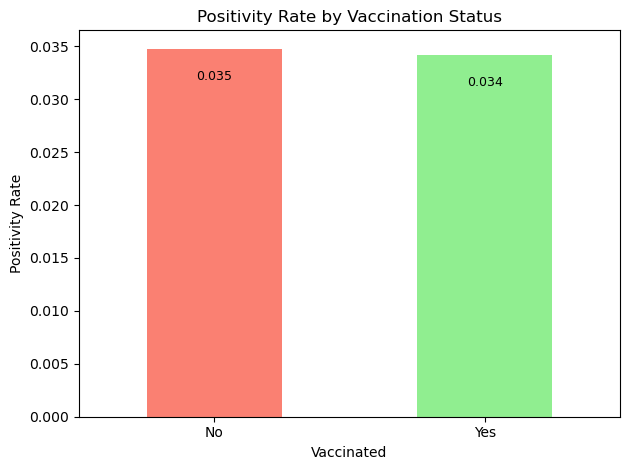

In [9]:
# Merging patient vaccination info with positivity
tests_merged = tests.merge(patients, on="patient_id", how="left")
tests_merged["vaccinated"] = tests_merged["pt_has_vaccination_y_n"] == "Yes"

# Calculate positivity rate by vaccination status
vacc_positivity = tests_merged.groupby("vaccinated")["is_positive"].mean()

# Positivity by vaccination status with labels
ax = vacc_positivity.plot(kind="bar", color=["salmon","lightgreen"])
plt.title("Positivity Rate by Vaccination Status")
plt.xlabel("Vaccinated")
plt.ylabel("Positivity Rate")
plt.xticks([0,1], ["No", "Yes"], rotation=0)

# Adding data labels
for i, v in enumerate(vacc_positivity):
    ax.text(i, v - 0.002, f"{v:.3f}", ha='center', va='top', color='black', fontsize=9)

plt.tight_layout()
plt.savefig("../dashboards/positivity_by_vaccination.png")
plt.show()

### Observation:

Vaccinated individuals show slightly lower positivity, but the difference is very small.

This suggests that vaccination status alone may not strongly explain infection risk in this dataset. 
I’d likely need to break this down further by disease or age group to see if any clearer patterns emerge.

In [10]:
print("Positivity rate by vaccination status:")
print(vacc_positivity)

print("Chart saved to dashboards folder.")

Positivity rate by vaccination status:
vaccinated
False    0.034770
True     0.034206
Name: is_positive, dtype: float64
Chart saved to dashboards folder.
